In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection, LineCollection

In [2]:
def get_rects_verts_2d(rects):
    return torch.stack(
        [
            rects[:, 0, :2],
            rects[:, 0, :2] + rects[:, 1, :2],
            rects[:, 0, :2] + rects[:, 1, :2] + rects[:, 2, :2],
            rects[:, 0, :2] + rects[:, 2, :2],
        ],
        dim=1,
    )


def rects_edges_2d(rects):
    verts = get_rects_verts_2d(rects)
    edges = torch.stack(
        [
            verts[:, (0, 1)],
            verts[:, (1, 2)],
            verts[:, (2, 3)],
            verts[:, (3, 0)],
        ],
        dim=1,
    )
    return edges

    # d = cross / np.linalg.norm(pb - pa_arr) * 0.5

In [3]:
device = torch.device("cpu")


def get_fov_centers_2d(npx_xy, mmppx_xy, device: torch.device):
    gridx, gridy = torch.meshgrid(
        torch.arange(npx_xy[0], device=device),
        torch.arange(npx_xy[1], device=device),
        indexing="ij",
    )
    fov_dims = npx_xy * mmppx_xy
    return (
        torch.stack((gridx, gridy), dim=-1) + torch.tensor([0.5, 0.5])
    ) * mmppx_xy - fov_dims * 0.5

In [4]:
pa_arr = get_fov_centers_2d(torch.tensor([1, 1]), torch.tensor([1, 1]), device)

In [5]:
def get_rays(
    pa_arr: torch.Tensor, pb_arr: torch.Tensor, device: torch.device
) -> torch.Tensor:
    """
    Get rays from array of points a and array of points b
    """
    npa = pa_arr.shape[0]
    npb = pb_arr.shape[0]
    return torch.stack(
        (
            pa_arr.view(-1, 1, 2).expand(-1, npb, -1),
            pb_arr.view(1, -1, 2).expand(npa, -1, -1),
        ),
        dim=2,
    )


def abrays_cut_rects_2d(
    pa_arr: torch.Tensor,
    pb_arr: torch.Tensor,
    edges: torch.Tensor,
    device: torch.device,
):
    """
    Cut rays with line segments (edges)
    """

    n_pa = pa_arr.shape[0]
    n_pb = pb_arr.shape[0]
    n_rects = edges.shape[0]
    rays = get_rays(pa_arr, pb_arr, device)
    v1 = rays[:, :, 1] - rays[:, :, 0]
    v2 = edges[:, :, 0] - edges[:, :, 1]
    # try:
    v3 = edges[:, :, 0].view(1, -1, 4, 2).expand(n_pa, -1, -1, -1) - pa_arr.view(
        -1, 1, 1, 2
    ).expand(-1, n_rects, 4, -1)

    # cramer's rule
    v1 = v1.view(n_pa, n_pb, 1, 1, 2).expand(-1, -1, n_rects, 4, -1)
    v2 = v2.view(1, 1, n_rects, 4, 2).expand(n_pa, n_pb, -1, -1, -1)
    v3 = v3.view(n_pa, 1, n_rects, 4, 2).expand(-1, n_pb, -1, -1, -1)
    det = v1[:, :, :, :, 0] * v2[:, :, :, :, 1] - v1[:, :, :, :, 1] * v2[:, :, :, :, 0]
    t = torch.where(
        det != 0,
        (v3[:, :, :, :, 0] * v2[:, :, :, :, 1] - v2[:, :, :, :, 0] * v3[:, :, :, :, 1])
        / det,
        -1,
    )
    s = torch.where(
        det != 0,
        (v1[:, :, :, :, 0] * v3[:, :, :, :, 1] - v1[:, :, :, :, 1] * v3[:, :, :, :, 0])
        / det,
        -1,
    )
    t[t > 1] = float("nan")
    t[t < 0] = float("nan")
    t = torch.where((s <= 1) * (s >= 0), t, float("nan"))
    index = torch.argwhere(~torch.isnan(t))
    return t[index[:, 0], index[:, 1], index[:, 2], index[:, 3]], index


rects = torch.tensor(
    [
        [[20, 0.0], [1.0, 0.0], [0.0, 2.0]],
        [[20, 3.0], [1.0, 0.0], [0.0, 2.0]],
        [[89.5, 4.0], [1.0, 0.0], [0.0, 2.0]],
    ],
    device=device,
)
verts = get_rects_verts_2d(rects)
pa_arr = get_fov_centers_2d(torch.tensor([1, 2]), torch.tensor([1, 2]), device)
pb_arr = torch.tensor([90, 5]).view(1, 2)
print(verts.shape)
edges = rects_edges_2d(rects)

t, t_idx = abrays_cut_rects_2d(pa_arr.view(-1, 2), pb_arr, edges, device)
print(t.shape)

torch.Size([3, 4, 2])
torch.Size([6])


In [6]:
rays = get_rays(pa_arr.view(-1, 2), pb_arr, device)
rays_cut = rays[t_idx[:, 0], t_idx[:, 1]]
cuts = rays_cut[:, 0] + t.view(-1, 1) * (rays_cut[:, 1] - rays_cut[:, 0])
# rays_len = torch.linalg.norm(rays_cut[:, 1] - rays_cut[:, 0], dim=1)
# mus = torch.tensor([3.5, 3.5]).view(rects.shape[0], 1)
print(rays_cut)
print(cuts)

tensor([[[ 0., -1.],
         [90.,  5.]],

        [[ 0., -1.],
         [90.,  5.]],

        [[ 0., -1.],
         [90.,  5.]],

        [[ 0.,  1.],
         [90.,  5.]],

        [[ 0.,  1.],
         [90.,  5.]],

        [[ 0.,  1.],
         [90.,  5.]]])
tensor([[21.0000,  0.4000],
        [20.0000,  0.3333],
        [89.5000,  4.9667],
        [21.0000,  1.9333],
        [20.0000,  1.8889],
        [89.5000,  4.9778]])


torch.Size([1, 2, 2])


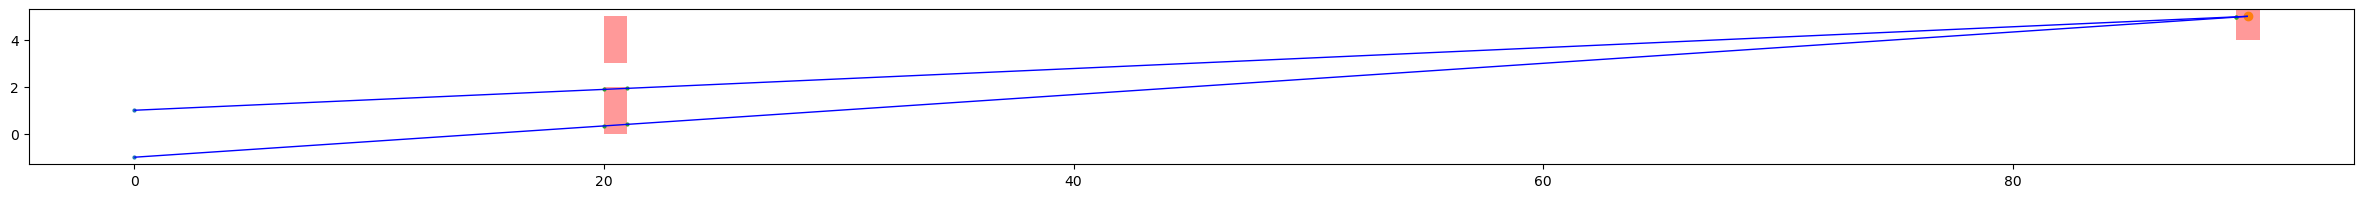

In [7]:
print(pa_arr.shape)
fig = plt.figure(figsize=(30, 10))
ax = fig.add_subplot(111)
ax.plot(pa_arr.view(-1, 2)[:, 0], pa_arr.view(-1, 2)[:, 1], "o", ms=2)
ax.plot(pb_arr[:, 0], pb_arr[:, 1], "o")
lines = rays.view(-1, 2, 2).numpy()
line_segments = LineCollection(lines, colors="blue", linewidths=1)
ax.plot(cuts[:, 0], cuts[:, 1], "o", ms=2)
ax.add_collection(line_segments)
patches = []
for vert in verts:
    polygon = Polygon(vert, closed=True)
    patches.append(polygon)

p = PatchCollection(patches, alpha=0.4, fc="r")
ax.add_collection(p)
ax.set_aspect("equal")
# ax.set_ylim(-1, 10)
plt.show()

In [8]:
def plot_cuboids(cuboids, ax, alpha=1, fc="r", ec="none"):
    verts = get_rects_verts_2d(cuboids.view(-1, 4, 3))
    patches = []
    for vert in verts:
        polygon = Polygon(vert, closed=True)
        patches.append(polygon)

    p = PatchCollection(patches, fc=fc, ec=ec, alpha=alpha)
    ax.add_collection(p)


def get_scanner_cuboids(scanner_id):
    scanner_cuboids_data_dir = "scanner_cuboids_data"
    with np.load(
        f"{scanner_cuboids_data_dir}/scanner_cuboids_{scanner_id:03d}.npz"
    ) as data:
        xtal_cuboids = torch.tensor(data["crystal cuboids"])
        plate_cuboids = torch.tensor(data["plate cuboids"])
    return xtal_cuboids, plate_cuboids


def plot_scanner(xtal_cuboids, plate_cuboids, ax):
    plot_cuboids(xtal_cuboids, ax, alpha=1, fc="orange")
    plot_cuboids(plate_cuboids, ax, fc="darkgray")


def plot_cuboid(id, xtal_cuboids, ax, fc="r", ec="none"):
    plot_cuboids(xtal_cuboids.view(-1, 4, 3)[id], ax, fc=fc, ec=ec, alpha=0.5)

In [9]:
def get_rect_center_2d(rect):
    return rect[0, :2] + 0.5 * rect[1, :2] + 0.5 * rect[2, :2]

torch.Size([4, 4, 2])
16


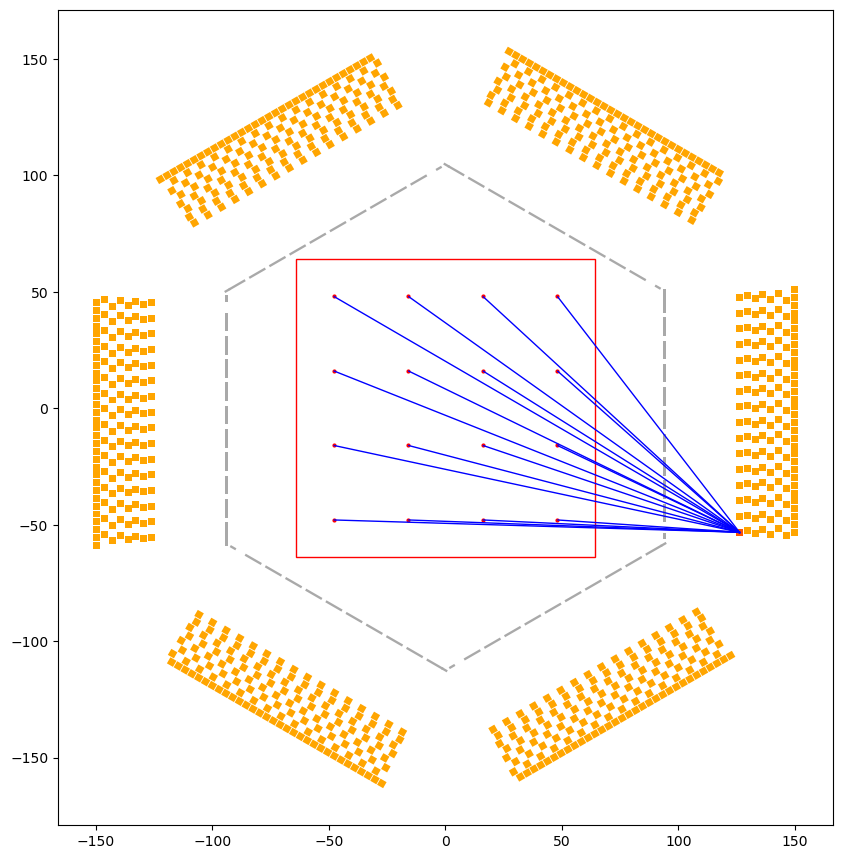

In [13]:
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([32, 32])
fov_dims = fov_npx * fov_mmppx

ppdf = torch.full((fov_npx[0], fov_npx[1]), float("nan"))
fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111)
ax.set_aspect("equal")
scanner_id = 0
xtal_id = 0
xtal_cuboids, plate_cuboids = get_scanner_cuboids(scanner_id)
plot_scanner(xtal_cuboids, plate_cuboids, ax)
plot_cuboid(xtal_id, xtal_cuboids, ax)
# ax.imshow(ppdf, extent=(-fov_dims[0] * 0.5, fov_dims[0] * 0.5, -fov_dims[1] * 0.5, fov_dims[1] * 0.5),origin="lower")
x = np.linspace(-fov_dims[0] * 0.5, fov_dims[0] * 0.5, fov_npx[0] + 1)
y = np.linspace(-fov_dims[1] * 0.5, fov_dims[1] * 0.5, fov_npx[1] + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, ppdf, edgecolors="none")
# ax.pcolormesh(ppdf, ,edgecolors="black", linewidth=0.5)
ax.add_patch(
    plt.Rectangle(
        -fov_dims * 0.5,
        fov_npx[0] * fov_mmppx[0],
        fov_npx[1] * fov_mmppx[1],
        fill=False,
        edgecolor="red",
    )
)
# ax.plot(0, 0)

pa_arr = get_fov_centers_2d(fov_npx, fov_mmppx, device)
print(pa_arr.shape)
pb_arr = get_rect_center_2d(xtal_cuboids.view(-1, 4, 3)[xtal_id])
ax.plot(pb_arr[0], pb_arr[1], "o", ms=1, color="b")
ax.plot(pa_arr.view(-1, 2)[:, 0], pa_arr.view(-1, 2)[:, 1], "o", ms=2, c="r")

rays = get_rays(pa_arr.view(-1, 2), pb_arr.view(-1, 2), device)
lines = rays.view(-1, 2, 2).numpy()
lines_segs = LineCollection(lines, colors="blue", linewidths=1)
print(len(lines))
ax.add_collection(lines_segs)
# ax.plot(cuts[:, 0], cuts[:, 1], "o", ms=2)

In [24]:
## Cut rays
rects = xtal_cuboids.view(-1, 4, 3)[xtal_id, :3, :2].view(1, 3, 2)
print(rects.shape)
edges = rects_edges_2d(rects)
t, t_idx = abrays_cut_rects_2d(pa_arr.view(-1, 2), pb_arr.view(1, 2), edges, device)
rays_cut = rays[t_idx[:, 0], t_idx[:, 1]]
dl_len_self = torch.linalg.norm(rays_cut[:, 1] - rays_cut[:, 0], dim=1) * (1 - t)
cuts = rays_cut[:, 0] + t.view(-1, 1) * (rays_cut[:, 1] - rays_cut[:, 0])
print(dl_len_self.shape)

torch.Size([1, 3, 2])
torch.Size([16])


In [32]:
## cut rays on the plates and other crystals
rects = plate_cuboids.view(-1, 4, 3)[:, :3, :2]
edges = rects_edges_2d(rects)
t, t_idx = abrays_cut_rects_2d(pa_arr.view(-1, 2), pb_arr.view(1, 2), edges, device)
rays_cut = rays[t_idx[:, 0], t_idx[:, 1]]
rays_len = torch.linalg.norm(rays_cut[:, 1] - rays_cut[:, 0], dim=1)[::2]
t_diff = torch.abs(t[1::2] - t[::2])
print(f'{"shape of ray_len:":18s}', rays_len.shape)
print(f'{"shape of t_diff:":18s}', t_diff.shape)
# dl_len_plate = torch.linalg.norm(rays_cut[:, 1] - rays_cut[:, 0], dim=1)*(1-t)
# print(t.shape)
# print(t_idx.shape)
# print(t_idx)

shape of ray_len:  torch.Size([10])
shape of t_diff:   torch.Size([10])


In [54]:
# set mu_tensor
mu_tensor_plate = torch.tensor(3.5).expand(plate_cuboids.view(-1, 4, 3).shape[0])
mu_tensor_xtal = torch.tensor(0.475).expand(xtal_cuboids.view(-1, 4, 3).shape[0])
print(f'{"shape of mu_tensor_plate:":32s}', mu_tensor_plate.shape)
print(f'{"shape of mu_tensor_xtal:":32s}', mu_tensor_xtal.shape)
mu_tensor_other = torch.cat((mu_tensor_plate, mu_tensor_xtal[1:]))
print(f'{"shape of mu_tensor_other:":32s}', mu_tensor_other.shape)

shape of mu_tensor_plate:        torch.Size([72])
shape of mu_tensor_xtal:         torch.Size([864])
shape of mu_tensor_other:        torch.Size([935])


In [78]:
scanner_id = 0
xtal_id = 20
xtal_cuboids, plate_cuboids = get_scanner_cuboids(scanner_id)
# concatenate plate cubois and other xtal cuboids
rays = get_rays(pa_arr.view(-1, 2), pb_arr.view(-1, 2), device)
other_cuboids = torch.cat(
    [
        plate_cuboids.view(-1, 4, 3),
        xtal_cuboids.view(-1, 4, 3)[:xtal_id],
        xtal_cuboids.view(-1, 4, 3)[xtal_id + 1 :],
    ]
)
pa_arr = get_fov_centers_2d(fov_npx, fov_mmppx, device)
pb_arr = get_rect_center_2d(xtal_cuboids.view(-1, 4, 3)[xtal_id])
n_pa = pa_arr.view(-1, 2).shape[0]
n_pb = pb_arr.view(-1, 2).shape[0]
edges_self = rects_edges_2d(xtal_cuboids.view(-1, 4, 3)[xtal_id, :3, :2].view(1, 3, 2))
edges_other = rects_edges_2d(other_cuboids[:, :3, :2])
n_other_cuboids = other_cuboids.shape[0]
t_self, t_idx_self = abrays_cut_rects_2d(
    pa_arr.view(-1, 2), pb_arr.view(1, 2), edges_self, device
)
t_other, t_idx_other = abrays_cut_rects_2d(
    pa_arr.view(-1, 2), pb_arr.view(1, 2), edges_other, device
)
rays_cut_self = rays[t_idx_self[:, 0], t_idx_self[:, 1]]
rays_cut_other = rays[t_idx_other[:, 0], t_idx_other[:, 1]]
cuts_other = rays_cut_other[:, 0] + t_other.view(-1, 1) * (
    rays_cut_other[:, 1] - rays_cut_other[:, 0]
)
cuts_self = rays_cut_self[:, 0] + t_self.view(-1, 1) * (
    rays_cut_self[:, 1] - rays_cut_self[:, 0]
)
dl_other = torch.abs(t_other[1::2] - t_other[::2]) * torch.linalg.norm(
    rays_cut_other[::2, 1] - rays_cut_other[::2, 0], dim=1
)
t_idx_other_unique = t_idx_other[::2]
mu_other = mu_tensor_other[t_idx_other_unique[:, 2]]
dlmu_attenu_tensor = torch.sparse_coo_tensor(
    t_idx_other_unique[:, :3].t(), dl_other * mu_other, (n_pa, n_pb, n_other_cuboids)
)
dl_mu_absorb = (
    torch.linalg.norm(rays_cut_self[:, 1] - rays_cut_self[:, 0], dim=1)
    * (1 - t_self)
    * 0.475
)
print("shape of t_self", t_self.shape)
print("shape of t_idx_other_unique", t_idx_other_unique.shape)
print("shape of dl_other", dl_other.shape)
print("shape of mu_other", mu_other.shape)
print("shape of dlmu_attenu_tensor", dlmu_attenu_tensor.shape)
print(dlmu_attenu_tensor.shape)
# dl_mu_sum_attenuate = torch.linalg.norm(rays_cut_other[:, 1] - rays_cut_other[:, 0], dim=1) * (1 - t_other) * mu_tensor_other

# dl_len_self = torch.linalg.norm(rays_cut[:, 1] - rays_cut[:, 0], dim=1)*(1-t)

shape of t_self torch.Size([16])
shape of t_idx_other_unique torch.Size([27, 4])
shape of dl_other torch.Size([27])
shape of mu_other torch.Size([27])
shape of dlmu_attenu_tensor torch.Size([16, 1, 935])
torch.Size([16, 1, 935])


In [82]:
dlmu_attenu_sum = torch.sparse.sum(dlmu_attenu_tensor, dim=2)
print(dlmu_attenu_sum.shape)

torch.Size([16, 1])


In [ ]:

fig = plt.figure(figsize=(32, 32))
ax = fig.add_subplot(111)
ax.set_aspect("equal")

plot_scanner(xtal_cuboids, plate_cuboids, ax)
plot_cuboid(xtal_id, xtal_cuboids, ax)
# ax.imshow(ppdf, extent=(-fov_dims[0] * 0.5, fov_dims[0] * 0.5, -fov_dims[1] * 0.5, fov_dims[1] * 0.5),origin="lower")
x = np.linspace(-fov_dims[0] * 0.5, fov_dims[0] * 0.5, fov_npx[0] + 1)
y = np.linspace(-fov_dims[1] * 0.5, fov_dims[1] * 0.5, fov_npx[1] + 1)
X, Y = np.meshgrid(x, y)
ax.pcolormesh(X, Y, ppdf, edgecolors="none")
# ax.pcolormesh(ppdf, ,edgecolors="black", linewidth=0.5)
ax.add_patch(
    plt.Rectangle(
        -fov_dims * 0.5,
        fov_npx[0] * fov_mmppx[0],
        fov_npx[1] * fov_mmppx[1],
        fill=False,
        edgecolor="red",
    )
)
# ax.plot(0, 0)


ax.plot(pb_arr[0], pb_arr[1], "o", ms=1, color="b")
ax.plot(pa_arr.view(-1, 2)[:, 0], pa_arr.view(-1, 2)[:, 1], "o", ms=2, c="r")
lines = rays.view(-1, 2, 2).numpy()
lines_segs = LineCollection(lines, colors="darkcyan", linewidths=1)
ax.add_collection(lines_segs)
ax.plot(cuts_other[:, 0], cuts_other[:, 1], "o", ms=2, c="blue")
# ax.set_xlim(90,110)
# ax.set_ylim(-60,0)